In [1]:
import pandas as pd
import numpy as np

In [2]:
import matplotlib.pyplot as plt
import seaborn as sns

In [3]:
df = pd.read_csv('kyphosis.csv')
df.head()

,Kyphosis,Age,Number,Start
0,absent,71,3,5
1,absent,158,3,14
2,present,128,4,5
3,absent,2,5,1
4,absent,1,4,15


In [14]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 81 entries, 0 to 80
Data columns (total 4 columns):
 #   Column    Non-Null Count  Dtype 
---  ------    --------------  ----- 
 0   Kyphosis  81 non-null     object
 1   Age       81 non-null     int64 
 2   Number    81 non-null     int64 
 3   Start     81 non-null     int64 
dtypes: int64(3), object(1)
memory usage: 2.7+ KB


In [4]:
from sklearn.model_selection import train_test_split

In [5]:
X = df.drop('Kyphosis', axis = 1)
y = df['Kyphosis']

X_train,X_test,y_train,y_test = train_test_split(X,y,test_size=0.3)

In [6]:
from sklearn.tree import DecisionTreeClassifier
d_tree = DecisionTreeClassifier()

In [7]:
d_tree.fit(X_train,y_train)

DecisionTreeClassifier()

In [8]:
pred = d_tree.predict(X_test)

In [18]:
from sklearn.metrics import classification_report,confusion_matrix,ConfusionMatrixDisplay

In [19]:
print (classification_report(y_test,pred))

              precision    recall  f1-score   support

      absent       0.78      0.82      0.80        17
     present       0.57      0.50      0.53         8

    accuracy                           0.72        25
   macro avg       0.67      0.66      0.67        25
weighted avg       0.71      0.72      0.71        25



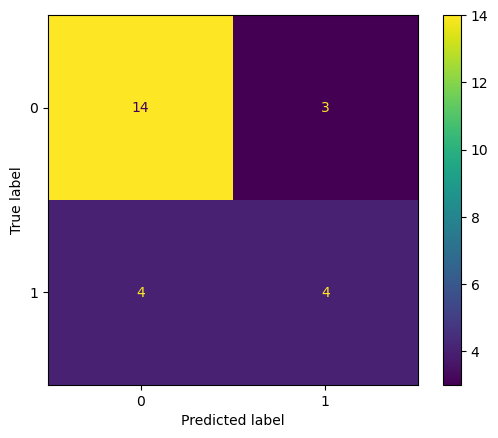

In [20]:
cm = confusion_matrix(y_test,pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm)
disp.plot()

plt.show()

In [22]:
from sklearn.ensemble import RandomForestClassifier
rfc = RandomForestClassifier(200)

In [23]:
rfc.fit(X_train,y_train)

RandomForestClassifier(n_estimators=200)

In [24]:
rfc_pred = rfc.predict(X_test)

In [25]:
print (classification_report(y_test, rfc_pred))

              precision    recall  f1-score   support

      absent       0.79      0.88      0.83        17
     present       0.67      0.50      0.57         8

    accuracy                           0.76        25
   macro avg       0.73      0.69      0.70        25
weighted avg       0.75      0.76      0.75        25



<Axes: >

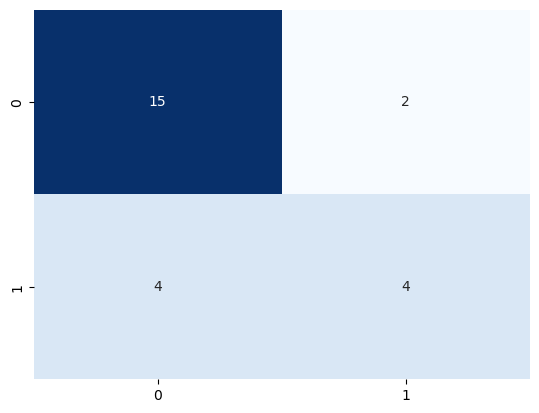

In [29]:
cm2 = confusion_matrix(y_test,rfc_pred)
sns.heatmap (cm2, cbar = False, annot = True, cmap = 'Blues')